<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<div style="text-align: center; margin-bottom: 10px;">
<div style="text-align: center; margin-bottom: 10px;">
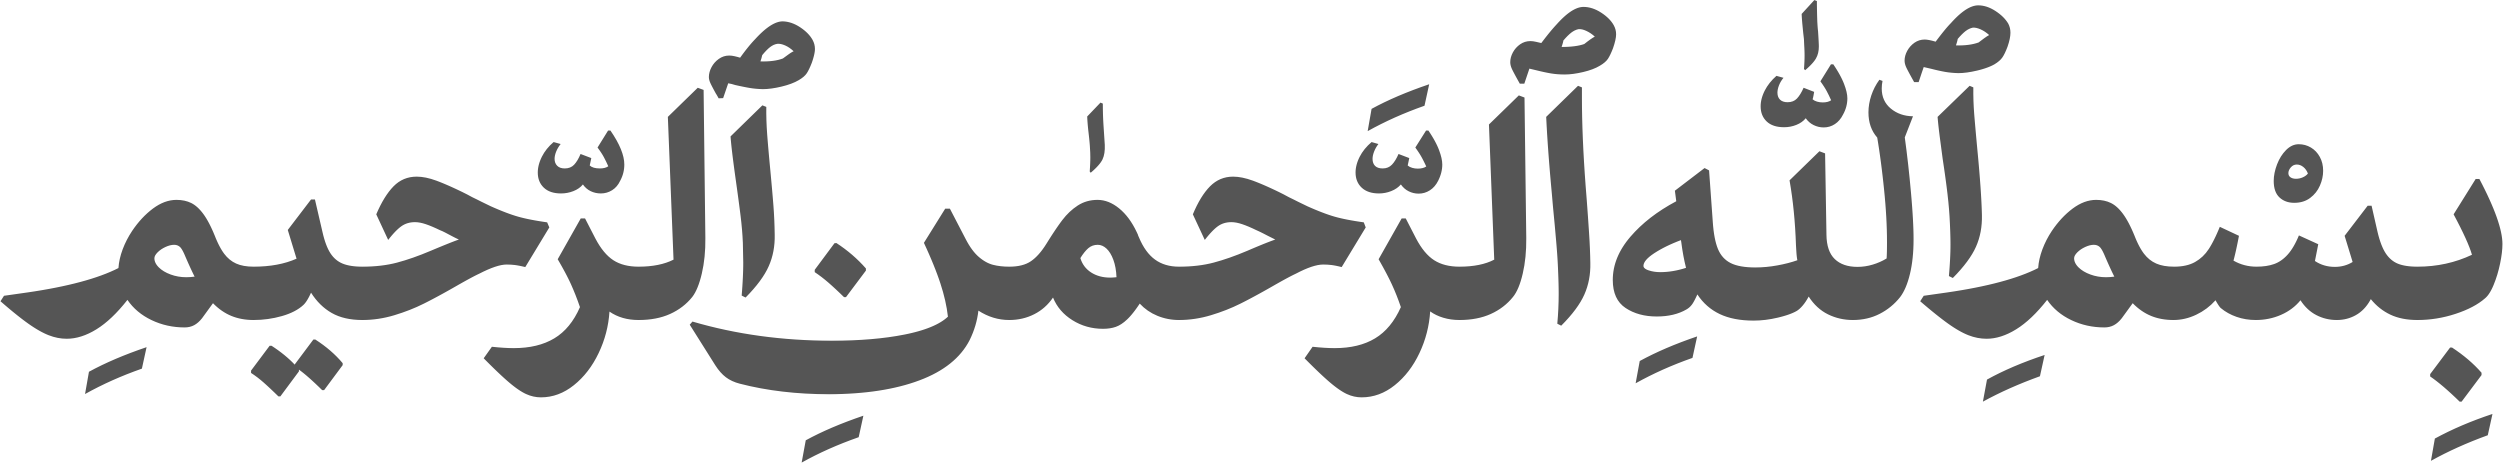
<div style="margin-top: 18px; display: flex; justify-content: center; align-items: center; gap: 30px;">
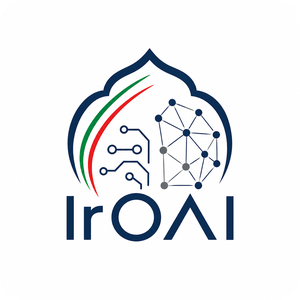
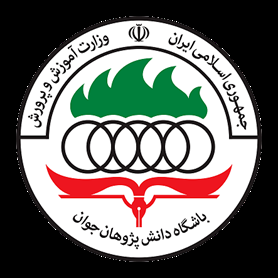
</div>
</div>
</div>
<h1 style="text-align: right; color: var(--jp-content-font-color1, #1e6bb8);">تمرین عملی المپیاد هوش مصنوعی — دوره دوم (۱۴۰۴-۱۴۰۵)</h1>
<h2 style="text-align: right; color: var(--jp-content-font-color1, #1e6bb8);">شبکه‌های عصبی کانولوشنی (CNN) و مفهوم Conv2d</h2>
<p style="text-align: right;"><b>مدت پیشنهادی:</b> ۳ ساعت</p>
<p style="text-align: right;"><b>موضوع:</b> یادگیری عمیق — پردازش تصویر، لایه‌های کانولوشنی و تجسم ویژگی‌ها در PyTorch</p>
<p style="text-align: right;">این یک تمرین آموزشی است؛ هیچ نمره‌ای از سامانه داوری دریافت نمی‌کند. هدف، یادگیری و بررسی نتیجه کار خودتان است.</p>
</div>


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h3 style="text-align: right; color: var(--jp-content-font-color1, #1e6bb8);">مقدمه و مفاهیم پایه‌ای شبکه‌های عصبی کانولوشنی</h3>
<p style="text-align: right;">شبکه‌های عصبی عمیق معمولی (MLP) برای داده‌های تصویری به دلیل تعداد بسیار زیاد پارامترها و عدم حفظ ساختار مکانی پیکسل‌ها مناسب نیستند. شبکه‌های کانولوشنی (CNN) با استفاده از <b>اشتراک وزن‌ها (Weight Sharing)</b> و <b>میدان‌های دریافت محلی (Local Receptive Fields)</b> این مشکل را حل می‌کنند.</p>
<p style="text-align: right;">اصلی‌ترین لایه در CNN لایه <b>Conv2d</b> است که یک فیلتر (کلاس/کرنل) را روی تصویر ورودی می‌لغزاند و ویژگی‌های بصری مانند لبه‌ها، بافت‌ها و الگوها را استخراج می‌کند.</p>
<p style="text-align: right;">فرمول ابعاد مکانی خروجی یک لایه کانولوشن دوبعدی برای تصویر ورودی به ابعاد $H \times W$ به‌صورت زیر محاسبه می‌شود:</p>
$$O = \left\lfloor \frac{H - K + 2P}{S} \right\rfloor + 1$$
<p style="text-align: right;">در این فرمول:</p>

<ul style="text-align: right;">
<li style="text-align: right;">$H$: اندازه ابعاد ورودی (مثلاً ۲۸ برای تصاویر Fashion-MNIST)</li>
<li style="text-align: right;">$K$: اندازه کرنل کانولوشن (Kernel Size)</li>
<li style="text-align: right;">$P$: مقدار پدینگ (Padding)</li>
<li style="text-align: right;">$S$: گام حرکت یا استراید (Stride)</li>
</ul>
</div>


In [ ]:
# Setup - read-only cell; do not edit
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

%matplotlib inline

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h3 style="text-align: right; color: var(--jp-content-font-color1, #1e6bb8);">بارگذاری داده‌ها، کاربرد transforms و ساختار DataLoader</h3>
<p style="text-align: right;">در این بخش، داده‌های مجموعه داده <b>Fashion-MNIST</b> بارگذاری شده و دو ابزار کلیدی <code>transforms</code> و <code>DataLoader</code> استفاده می‌شوند:</p>

<h4 style="text-align: right; color: var(--jp-content-font-color1, #1e6bb8);">۱. لایه پیش‌پردازش <code>transforms</code> و دلیل استفاده از آن</h4>
<p style="text-align: right;">تصاویر خام ورودی به‌صورت فایل‌های تصویری با دامنه پیکسل $[۰, ۲۵۵]$ و آرایش $(H \times W \times C)$ هستند. <code>transforms</code> این فرآیند را به‌صورت زنجیره‌ای استاندارد می‌کند:</p>

<ul style="text-align: right;">
<li style="text-align: right;"><code>ToTensor()</code>: تصویر خام را به تانسور اعشاری PyTorch با آرایش $(C \times H \times W)$ و دامنه اعشاری $[۰.۰, ۱.۰]$ تبدیل می‌کند. <b>چرا استفاده می‌کنیم؟</b> چون لایه‌های ریاضی PyTorch فقط روی تانسورهای اعشاری با این آرایش کار می‌کنند.</li>
<li style="text-align: right;"><code>Normalize((0.5,), (0.5,))</code>: مقادیر پیکسل‌ها را با فرمول $(x - \mu) / \sigma$ نرمال‌سازی می‌کند تا به دامنه $[-۱.۰, ۱.۰]$ منتقل شوند. <b>چرا استفاده می‌کنیم؟</b> صفر-مرکز کردن داده‌ها (Zero-Centering) مانع از انفجار/محو گرادیان‌ها شده و انتشار گرادیان در الگوریتم Adam/SGD را بسیار سریع‌تر و پایدارتر می‌کند.</li>
</ul>

<h4 style="text-align: right; color: var(--jp-content-font-color1, #1e6bb8);">۲. ساختار <code>DataLoader</code> و دلیل استفاده از آن</h4>
<p style="text-align: right;">کلاس <code>DataLoader</code> وظیفه بسته‌بندی داده‌ها، دسته‌بندی (Batching) و بارگذاری موازی را بر عهده دارد:</p>

<ul style="text-align: right;">
<li style="text-align: right;"><b>دسته‌بندی (<code>batch_size=64</code>):</b> <b>چرا استفاده می‌کنیم؟</b> بارگذاری تک‌تک تصاویر بسیار کند است و بارگذاری یکجای تمام ۶۰ هزار تصویر حافظه RAM/GPU را پر می‌کند. دسته‌بندی داده‌ها امکان محاسبات موازی ماتریکسی روی GPU/CPU را فراهم می‌سازد.</li>
<li style="text-align: right;"><b>برهم‌زدن تصادفی (<code>shuffle=True</code>):</b> <b>چرا استفاده می‌کنیم؟</b> برهم زدن ترتیب داده‌ها در ابتدای هر اپوک مانع از حفظ کردن ترتیب نمونه‌ها توسط شبکه شده و تعمیم‌پذیری مدل را افزایش می‌دهد.</li>
</ul>
</div>


In [ ]:
# Demo - read-only: Load Fashion-MNIST dataset and preview sample images

# --- EXPLANATION & WHY WE USE TRANSFORMS ---
# 'transforms' defines the preprocessing pipeline applied to raw dataset images:
# 1. ToTensor(): Converts PIL Images or NumPy arrays (pixel values [0, 255], shape HxWxC)
#    into PyTorch Floating Point Tensors (pixel values [0.0, 1.0], shape CxHxW).
#    WHY: PyTorch neural network layers require float tensors in channel-first format.
# 2. Normalize((0.5,), (0.5,)): Standardizes pixel values using (x - mean) / std.
#    With mean=0.5 and std=0.5, pixel values in [0.0, 1.0] are shifted to [-1.0, 1.0].
#    WHY: Zero-centering inputs prevents gradient vanishing/explosion and speeds up training.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Download and instantiate Fashion-MNIST train and test dataset objects
train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform
)

# --- EXPLANATION & WHY WE USE DATALOADER ---
# 'DataLoader' wraps a PyTorch Dataset and manages batching, shuffling, and iteration:
# 1. batch_size=64: Combines 64 single images into a mini-batch tensor of shape (64, 1, 28, 28).
#    WHY: Processing images one-by-one is slow, while loading all images at once exhausts memory.
#    Mini-batches allow parallel hardware matrix operations on GPU/CPU.
# 2. shuffle=True: Randomizes sample order at the start of each training epoch.
#    WHY: Prevents the network from learning order bias and improves generalization.
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Inspect a single mini-batch from train_loader
images, labels = next(iter(train_loader))
fig, axs = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axs.flat):
    # Unnormalize for visualization: img_unnorm = img * std + mean = img * 0.5 + 0.5
    img = images[i].squeeze().numpy() * 0.5 + 0.5
    ax.imshow(img, cmap='gray')
    ax.set_title(f"{classes[labels[i]]}", fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h3 style="text-align: right; color: var(--jp-content-font-color1, #1e6bb8);">بخش اول: محاسبه ابعاد خروجی Conv2d و بررسی تاثیر Stride و Padding</h3>
<p style="text-align: right;">در این بخش تابع <code>compute_conv_output_shape</code> را پیاده‌سازی کنید تا ابعاد مکانی خروجی لایه کانولوشن را محاسبه کند. سپس صحت عملکرد تابع خود را با لایه واقعی <code>nn.Conv2d</code> در PyTorch بررسی کنید.</p>
</div>


In [ ]:
# Phase 1: Output shape formula and parameter exploration
def compute_conv_output_shape(in_size, kernel_size, stride=1, padding=0):
    """Compute the spatial output shape of a 2D convolution.
    
    Args:
        in_size (int): Input spatial size (height/width)
        kernel_size (int): Convolution kernel size
        stride (int): Stride step size
        padding (int): Zero-padding size
    Returns:
        int: Spatial output dimension
    """
    return (in_size - kernel_size + 2 * padding) // stride + 1

# Test formula with different parameters on 28x28 input
test_params = [
    (28, 3, 1, 1),
    (28, 3, 2, 1),
    (28, 5, 1, 0),
    (28, 5, 2, 2)
]

for in_s, k, s, p in test_params:
    out_s = compute_conv_output_shape(in_s, k, s, p)
    print(f"Input: {in_s}x{in_s} | Kernel: {k}x{k} | Stride: {s} | Padding: {p} => Output: {out_s}x{out_s}")
    
    # Verify with PyTorch nn.Conv2d module
    conv = nn.Conv2d(1, 16, kernel_size=k, stride=s, padding=p)
    x_dummy = torch.randn(1, 1, in_s, in_s)
    actual_shape = conv(x_dummy).shape[2]
    assert out_s == actual_shape, f"Mismatch: formula={out_s}, conv={actual_shape}"

print("All output shape tests passed successfully!")


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h3 style="text-align: right; color: var(--jp-content-font-color1, #1e6bb8);">بحث کنید: تحلیل پارامترهای Stride و Padding (پاسخ مرجع)</h3>
<p style="text-align: right;"><b>سوال ۱:</b> چگونه می‌توان با تنظیم همزمان <code>padding</code> و <code>stride</code>، ابعاد مکانی خروجی را دقیقا برابر با ابعاد ورودی ($۲۸ \times ۲۸$) نگه داشت (Same Padding)؟</p>
<p style="text-align: right;"><b>پاسخ ۱:</b> برای ثبات ابعاد مکانی ($O = H$) هنگام استفاده از گام $S = 1$، باید پدینگ برابر با $P = \lfloor (K - 1) / 2 \rfloor$ قرار گیرد. برای مثال با فیلتر $۳ \times ۳$ ($K = 3$)، قرار دادن $P = 1$ باعث می‌شود ابعاد خروجی دقیقا برابر با ابعاد ورودی ($۲۸ \times ۲۸$) باقی بماند.</p>
<p style="text-align: right;"><b>سوال ۲:</b> افزایش گام حرکت (<code>stride=2</code>) چه تاثیری بر حجم محاسبات لایه‌های بعدی و نرخ کاهش ابعاد تصویر دارد؟</p>
<p style="text-align: right;"><b>پاسخ ۲:</b> افزایش گام به $S = 2$ ابعاد مکانی تصویر خروجی را نصف ($۱۴ \times ۱۴$) می‌کند. این امر مساحت تصویر خروجی را ۴ برابر کاهش داده و تعداد محاسبات ضرب و جمع و حجم حافظه مورد نیاز برای لایه‌های بعدی را به‌شدت کاهش می‌دهد.</p>
</div>


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h3 style="text-align: right; color: var(--jp-content-font-color1, #1e6bb8);">بخش دوم: ساخت معماری شبکه‌ی عصبی کانولوشنی SimpleCNN و مفهوم MaxPool2d</h3>
<p style="text-align: right;">یک مدل کانولوشنی با نام <code>SimpleCNN</code> کلاس‌بندی ۱۰‌گانه‌ی Fashion-MNIST طراحی کنید که شامل لایه‌های زیر باشد:</p>

<h4 style="text-align: right; color: var(--jp-content-font-color1, #1e6bb8);">مفهوم <code>MaxPool2d</code> و دلیل استفاده از آن:</h4>
<p style="text-align: right;">لایه <b>MaxPool2d</b> یک پنجره لغزان (مثلا $۲ \times ۲$) را روی نقشه ویژگی می‌لغزاند و فقط <b>بیشترین مقدار (Max Activation)</b> را استخراج می‌کند.</p>

<ul style="text-align: right;">
<li style="text-align: right;"><b>کاهش ابعاد مکانی و حجم محاسبات:</b> با قرار دادن <code>kernel_size=2, stride=2</code>، طول و عرض نقشه ویژگی نصف می‌شود (مثلا $۲۸ \times ۲۸ 	o ۱۴ \times ۱۴$). این امر مساحت را ۴ برابر کاهش داده و سرعت آموزش را به شدت افزایش می‌دهد.</li>
<li style="text-align: right;"><b>ناوردا بودن در برابر جابجایی مکانی (Translation Invariance):</b> اگر الگوی کشف‌شده (مثل لبه یقه لباس) چند پیکسل جابجا شود، بیشترین مقدار پنجره استخراج تغییر نمی‌کند و شبکه در برابر جابجایی جزیی مقاوم می‌شود.</li>
<li style="text-align: right;"><b>گسترش میدان دریافت (Receptive Field):</b> کمک می‌کند لایه‌های عمیق‌تر تصویر را در ابعاد وسیع‌تر و انتزاعی‌تری مشاهده کنند.</li>
</ul>

<h4 style="text-align: right; color: var(--jp-content-font-color1, #1e6bb8);">مشخصات معماری شبکه:</h4>
<ul style="text-align: right;">
<li style="text-align: right;"><b>بلوک ۱:</b> لایه کانولوشن (ورودی ۱ کانال، خروجی ۱۶ کانال، کرنل $۳ \times ۳$، استراید ۱، پدینگ ۱) + تابع فعال‌ساز ReLU + لایه MaxPool2d (کرنل ۲، استراید ۲). خروجی این لایه ابعاد $۱۴ \times ۱۴$ خواهد داشت.</li>
<li style="text-align: right;"><b>بلوک ۲:</b> لایه کانولوشن (ورودی ۱۶ کانال، خروجی ۳۲ کانال، کرنل $۳ \times ۳$، استراید ۱، پدینگ ۱) + تابع فعال‌ساز ReLU + لایه MaxPool2d (کرنل ۲، استراید ۲). خروجی این لایه ابعاد $۷ \times ۷$ خواهد داشت.</li>
<li style="text-align: right;"><b>سر کلاسیفایر (FC):</b> لایه خطی <code>nn.Linear</code> که تانسور تخت‌شده به ابعاد $۳۲ \times ۷ \times ۷ = ۱۵۶۸$ را به ۱۰ کلاس نگاشت می‌دهد.</li>
</ul>
</div>


In [ ]:
# Phase 2: SimpleCNN Model Architecture

# --- EXPLANATION & WHY WE USE MAXPOOL2D ---
# 'MaxPool2d(kernel_size=2, stride=2)' downsamples spatial feature maps:
# 1. Takes the MAX value within each 2x2 window.
# 2. WHY: Halves height and width (e.g. 28x28 -> 14x14), reducing spatial area by 4x.
#    This reduces parameter/memory count in FC layers, speeds up computation,
#    and provides spatial translation invariance (resistance to small shifts/rotations).

class SimpleCNN(nn.Module):
    """2-Layer Convolutional Neural Network for Fashion-MNIST classification."""
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        # Conv Block 1: 1 -> 16 channels, 3x3 kernel, stride=1, padding=1
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)  # Downsamples 28x28 -> 14x14

        # Conv Block 2: 16 -> 32 channels, 3x3 kernel, stride=1, padding=1
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)  # Downsamples 14x14 -> 7x7

        # Classifier Head: 32 * 7 * 7 = 1568 -> 10 classes
        self.fc = nn.Linear(32 * 7 * 7, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

# Test model instantiation and forward pass
model_demo = SimpleCNN()
print(model_demo)
x_test = torch.randn(4, 1, 28, 28)
out_test = model_demo(x_test)
print("Output tensor shape:", out_test.shape)
assert out_test.shape == (4, 10), f"Expected shape (4, 10), got {out_test.shape}"
print("SimpleCNN architecture verification passed!")


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h3 style="text-align: right; color: var(--jp-content-font-color1, #1e6bb8);">بخش سوم: پیاده‌سازی حلقه آموزش (Training Loop) و ارزیابی</h3>
<p style="text-align: right;">تابع <code>train_and_evaluate</code> را برای آموزش مدل با استفاده از بهینه‌ساز <b>Adam</b> و تابع زیان <b>CrossEntropyLoss</b> به مدت ۵ اپوک پیاده‌سازی کنید. تابع باید میزان زیان (Loss) و دقت (Accuracy) روی داده‌های آموزش و تست را در هر اپوک محاسبه و گزارش کند.</p>
</div>


In [ ]:
# Phase 3: Model Training and Evaluation Function
def train_and_evaluate(model, train_loader, test_loader, epochs=5, lr=0.001, device="cpu"):
    """Train the CNN model and evaluate on the test loader.
    
    Args:
        model (nn.Module): The CNN model
        train_loader (DataLoader): Training dataloader
        test_loader (DataLoader): Testing dataloader
        epochs (int): Number of training epochs
        lr (float): Learning rate
        device (str): Computation device ('cuda' or 'cpu')
    Returns:
        tuple: (history_dict, final_test_accuracy)
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    model.to(device)

    history = {'train_loss': [], 'train_acc': [], 'test_acc': []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total_train += labels.size(0)
            correct_train += predicted.eq(labels).sum().item()

        epoch_loss = running_loss / total_train
        epoch_train_acc = correct_train / total_train

        # Evaluation on test set
        model.eval()
        correct_test = 0
        total_test = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                total_test += labels.size(0)
                correct_test += predicted.eq(labels).sum().item()

        epoch_test_acc = correct_test / total_test

        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_train_acc)
        history['test_acc'].append(epoch_test_acc)

        print(f"Epoch [{epoch+1}/{epochs}] - Loss: {epoch_loss:.4f} | Train Acc: {epoch_train_acc*100:.2f}% | Test Acc: {epoch_test_acc*100:.2f}%")

    return history, epoch_test_acc

# Instantiate and train model
model_trained = SimpleCNN()
history, final_acc = train_and_evaluate(model_trained, train_loader, test_loader, epochs=5, lr=0.001, device=device)


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h3 style="text-align: right; color: var(--jp-content-font-color1, #1e6bb8);">بحث کنید: مقایسه تعداد پارامترهای CNN با MLP (پاسخ مرجع)</h3>
<p style="text-align: right;">مدل <code>SimpleCNN</code> ما کلا دارای حدود ۵۱,۰۰۰ پارامتر قابل یادگیری است. اگر می‌خواستیم همین داده‌ها را با یک شبکه‌ی متراکم (MLP) با دو لایه‌ی پنهان ۵۱۲ و ۲۵۶ نوری پردازش کنیم، تعداد پارامترها به بیش از ۵۰۰,۰۰۰ می‌رسید.</p>
<p style="text-align: right;"><b>سوال:</b> چرا شبکه‌های کانولوشنی با وجود پارامترهای بسیار کمتر، عملکرد بسیار بهتری در داده‌های تصویری نسبت به شبکه‌های متراکم (MLP) ارائه می‌دهند؟ مفهوم <b>Weight Sharing</b> چه نقشی در این امر دارد؟</p>
<p style="text-align: right;"><b>پاسخ:</b> شبکه‌های کانولوشنی بر اساس دو اصل کلیدی طراحی شده‌اند:</p>

<ol style="text-align: right;">
<li style="text-align: right;"><b>میدان‌های دریافت محلی (Local Receptive Fields):</b> روابط مکانی پیکسل‌های همسایه حفظ می‌شود، در حالی که MLP تصویر را به‌صورت یک بردار یک‌بعدی تخت دیده و ساختار دو‌بعدی تصویر را از دست می‌دهد.</li>
<li style="text-align: right;"><b>اشتراک وزن‌ها (Weight Sharing):</b> یک فیلتر کانولوشنی (مثلا $۳ \times ۳$ دارای ۹ وزن) روی تمام مناطق تصویر لغزیده و الگوی بصری مشخصی را صرف‌نظر از موقعیت مکانیش شناسایی می‌کند (Translation Invariance). در MLP برای هر پیکسل وزن‌های جداگانه تعریف می‌شود که منجر به Overfitting شدید و انفجار تعداد پارامترها می‌گردد.</li>
</ol>
</div>


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h3 style="text-align: right; color: var(--jp-content-font-color1, #1e6bb8);">بخش چهارم (پیش‌نویس‌شده): تجسم وزن‌های فیلترها و نقشه‌های ویژگی (Feature Maps)</h3>
<p style="text-align: right;">یکی از جذابیت‌های شبکه‌های کانولوشنی قابلیت تجسم (Visualization) الگوهایی است که فیلترها یاد می‌گیرند.</p>
<p style="text-align: right;">سلول‌های زیر به‌صورت آماده نوشته شده‌اند. آن‌ها را اجرا کنید تا:</p>

<ul style="text-align: right;">
<li style="text-align: right;">وزن‌های ۱۶ فیلتر $۳ \times ۳$ لایه اول (<code>conv1</code>) نمایش داده شوند.</li>
<li style="text-align: right;">خروجی فعال‌سازی لایه‌ها (Feature Maps) برای یک تصویر نمونه ورودی رسم گردند.</li>
</ul>
</div>


In [ ]:
# Pre-written cell: Visualize learned weights of Conv1 filters
def visualize_conv1_weights(model):
    weights = model.conv1.weight.data.cpu()  # Shape: (16, 1, 3, 3)
    fig, axs = plt.subplots(4, 4, figsize=(6, 6))
    fig.suptitle("Learned 3x3 Filters in Conv1", fontsize=12)
    for i, ax in enumerate(axs.flat):
        w = weights[i, 0].numpy()
        w_norm = (w - w.min()) / (w.max() - w.min() + 1e-8)
        ax.imshow(w_norm, cmap="gray", interpolation="nearest")
        ax.set_title(f"Filter {i+1}", fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

visualize_conv1_weights(model_trained)


In [ ]:
# Pre-written cell: Visualize intermediate feature maps (activations) for a sample image
def visualize_feature_maps(model, image_tensor):
    model.eval()
    with torch.no_grad():
        img_input = image_tensor.unsqueeze(0).to(device)
        
        # Pass through Conv Block 1
        act1 = model.pool1(model.relu1(model.conv1(img_input))).cpu().squeeze(0)  # (16, 14, 14)
        # Pass through Conv Block 2
        act2 = model.pool2(model.relu2(model.conv2(act1.unsqueeze(0).to(device)))).cpu().squeeze(0)  # (32, 7, 7)

    # Input image
    plt.figure(figsize=(2.5, 2.5))
    plt.imshow(image_tensor.squeeze().numpy() * 0.5 + 0.5, cmap="gray")
    plt.title("Input Image", fontsize=10)
    plt.axis("off")
    plt.show()

    # Conv1 Feature Maps
    fig, axs = plt.subplots(2, 8, figsize=(12, 3.5))
    fig.suptitle("Feature Maps after Conv Block 1 (14x14)", fontsize=12)
    for i, ax in enumerate(axs.flat):
        ax.imshow(act1[i].numpy(), cmap="viridis")
        ax.set_title(f"Map {i+1}", fontsize=7)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

    # Conv2 Feature Maps (first 16)
    fig, axs = plt.subplots(2, 8, figsize=(12, 3.5))
    fig.suptitle("Feature Maps after Conv Block 2 (7x7)", fontsize=12)
    for i, ax in enumerate(axs.flat):
        ax.imshow(act2[i].numpy(), cmap="viridis")
        ax.set_title(f"Map {i+1}", fontsize=7)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

sample_img, sample_lbl = test_dataset[0]
print(f"Sample Image Label: {classes[sample_lbl]}")
visualize_feature_maps(model_trained, sample_img)


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h3 style="text-align: right; color: var(--jp-content-font-color1, #1e6bb8);">بحث کنید: تحلیل نقشه‌های ویژگی (Feature Maps) (پاسخ مرجع)</h3>
<p style="text-align: right;"><b>سوال ۱:</b> لایه اول (Conv1) چه نوع ویژگی‌هایی (مانند لبه‌های افقی/عمودی، کنتراست) را از تصویر استخراج کرده است؟</p>
<p style="text-align: right;"><b>پاسخ ۱:</b> فیلترهای لایه اول ویژگی‌های سطح پایین (Low-level Features) نظیر لبه‌های تیز افقی/عمودی، تغییرات شدت روشنایی و مرزهای تصویر را استخراج می‌کنند.</p>
<p style="text-align: right;"><b>سوال ۲:</b> تفاوت نقشه‌های ویژگی لایه دوم (Conv2 با ابعاد $۷ \times ۷$) نسبت به لایه اول در چیست؟ چرا خصوصیات این نقشه‌ها انتزاعی‌تر به‌نظر می‌رسند؟</p>
<p style="text-align: right;"><b>پاسخ ۲:</b> با افزایش عمق شبکه و استفاده از لایه‌های MaxPool2d، میدان دریافت (Receptive Field) گسترده‌تر می‌شود. لایه دوم ترکیب ویژگی‌های ساده اول را پردازش کرده و الگوهای پیچیده‌تر و انتزاعی‌تری (High-level Features) مانند فرم کلی آستین، یقه، بافت پارچه یا لبه‌های منحنی را رمزگذاری می‌کند.</p>
</div>


In [ ]:
# Evaluation cell - run it and compare with the reference value.
model_eval = SimpleCNN().to(device)
torch.manual_seed(SEED)
train_history_eval, test_acc_eval = train_and_evaluate(
    model_eval, train_loader, test_loader, epochs=5, lr=0.001, device=device
)
print(f"Final Test Accuracy (5 epochs, Adam lr=0.001): {test_acc_eval*100:.2f}%")


In [ ]:
# Reference cell - do NOT run it (kept for comparison only)
# Designer reference value (SEED=42, Fashion-MNIST, 5 epochs, Adam lr=0.001):
#   Final Test Accuracy: ~88.50% - 90.00%
# Student output should match or exceed ~87.00% test accuracy.


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h3 style="text-align: right; color: var(--jp-content-font-color1, #1e6bb8);">جمع‌بندی و نتیجه‌گیری</h3>
<p style="text-align: right;">در این تمرین مفاهیم کلیدی شبکه‌های عصبی کانولوشنی شامل موارد زیر را فرا گرفتید:</p>

<ul style="text-align: right;">
<li style="text-align: right;">فرمول محاسبه ابعاد مکانی خروجی با تغییر <code>kernel_size</code>، <code>stride</code> و <code>padding</code>.</li>
<li style="text-align: right;">طراحی معماری کانولوشنی متداول با لایه‌های <code>Conv2d</code>، <code>ReLU</code>، <code>MaxPool2d</code> و <code>Linear</code> در PyTorch.</li>
<li style="text-align: right;">تجسم وزن فیلترها و خروجی فعال‌سازی لایه‌ها (Feature Maps) برای درک نحوه استخراج ویژگی‌های بصری.</li>
</ul>
</div>
